# Laboratorio 9: Álbum real Panini Mundial 2026

**MM3014 Teoría de Probabilidades - Universidad del Valle de Guatemala**  
**Simulación Monte Carlo del Coupon Collector's Problem**

Este notebook extiende las etapas anteriores del laboratorio al caso real del álbum Panini Mundial 2026. El objetivo es responder cinco preguntas de decisión usando simulación reproducible y manteniendo el modelo de sobres trabajado previamente.

## 1. Librerías e importaciones

Se utilizan `NumPy` para la simulación, `pandas` para tablas de resultados y `matplotlib/seaborn` para visualización. La semilla global se fija para que las simulaciones sean reproducibles.

In [1]:
import os
from pathlib import Path

# Evita problemas de cache de matplotlib/fontconfig en entornos con HOME no escribible.
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp')
MPL_CACHE = Path('/private/tmp/matplotlib-cache')
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

SEED = 2026

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize': (10, 5.5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'grid.linestyle': '-',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.4f}'.format)

print(f'Semilla global: {SEED}')

Semilla global: 2026


## 2. Reutilización y adaptación de funciones

En los notebooks anteriores se implementaron dos ideas centrales:

- En `Lab7.ipynb` y `Etapa2.ipynb`, los sobres se simularon sin repetidas internas usando `np.random.choice(..., replace=False)`.
- En `Lab08.ipynb`, se incorporaron presupuesto, cajas y una regla de intercambio donde cada `K` repetidas se canjean por una estampa faltante.

Para escalar el modelo a `N = 980`, se conserva la misma lógica, pero se adapta la simulación a conteos. Si una corrida tiene `u` estampas distintas, el número de nuevas estampas en el siguiente sobre sigue una distribución hipergeométrica:

\[
X \sim \operatorname{Hipergeometrica}(N-u,\ u,\ S).
\]

Esto evita guardar un arreglo booleano o un conjunto por simulación y permite correr miles de repeticiones de forma eficiente.

In [2]:
def formato_q(x):
    """Formato monetario en quetzales."""
    return f'Q {x:,.2f}'


def ic_proporcion(p, n, z=1.96):
    """Intervalo normal aproximado para una proporción Monte Carlo."""
    return z * np.sqrt(p * (1 - p) / n)


def quantil_superior(x, q):
    """Cuantil empírico conservador: primer valor observado que alcanza el nivel q."""
    return int(np.quantile(x, q, method='higher'))


def resumen_vector(x):
    """Resumen descriptivo compacto para arreglos numéricos."""
    x = np.asarray(x)
    return {
        'media': x.mean(),
        'desv_est': x.std(ddof=1),
        'mediana': np.median(x),
        'p90': quantil_superior(x, 0.90),
        'p95': quantil_superior(x, 0.95),
        'p99': quantil_superior(x, 0.99),
    }


def simular_hasta_objetivo(N, S, objetivo, R, seed=SEED, K=None, max_sobres=10_000):
    """
    Simula R coleccionistas hasta alcanzar al menos `objetivo` estampas distintas.

    La simulación trabaja por conteos. En cada sobre se calcula cuántas estampas
    son nuevas con una distribución hipergeométrica, equivalente al modelo de
    sobres sin repetidas internas usado en las etapas previas.

    Si K no es None, cada K repetidas acumuladas se canjean por una estampa faltante.
    """
    rng = np.random.default_rng(seed)

    unicas = np.zeros(R, dtype=np.int32)
    repetidas = np.zeros(R, dtype=np.int32)
    creditos = np.zeros(R, dtype=np.int32)
    sobres = np.zeros(R, dtype=np.int32)

    activo = np.ones(R, dtype=bool)

    while activo.any():
        idx = np.flatnonzero(activo)

        nuevas = rng.hypergeometric(N - unicas[idx], unicas[idx], S)
        reps_pack = S - nuevas

        unicas[idx] += nuevas
        repetidas[idx] += reps_pack

        if K is not None:
            creditos_idx = creditos[idx] + reps_pack
            canjes = np.minimum(creditos_idx // K, N - unicas[idx])
            unicas[idx] += canjes
            creditos[idx] = creditos_idx - canjes * K

        sobres[idx] += 1
        activo = (unicas < objetivo) & (sobres < max_sobres)

    return {
        'sobres': sobres,
        'unicas': unicas,
        'repetidas': repetidas,
        'creditos': creditos,
    }


def simular_m_sobres(N, S, M, R, seed=SEED, K=None):
    """
    Simula R coleccionistas que compran exactamente M sobres.

    Devuelve estampas distintas, repetidas naturales y creditos de intercambio
    restantes al finalizar la compra.
    """
    rng = np.random.default_rng(seed)

    unicas = np.zeros(R, dtype=np.int32)
    repetidas = np.zeros(R, dtype=np.int32)
    creditos = np.zeros(R, dtype=np.int32)

    for _ in range(M):
        nuevas = rng.hypergeometric(N - unicas, unicas, S)
        reps_pack = S - nuevas

        unicas += nuevas
        repetidas += reps_pack

        if K is not None:
            creditos_actuales = creditos + reps_pack
            canjes = np.minimum(creditos_actuales // K, N - unicas)
            unicas += canjes
            creditos = creditos_actuales - canjes * K

    return {
        'unicas': unicas,
        'repetidas': repetidas,
        'creditos': creditos,
    }


def costo_minimo_para_m_sobres(M, precio_sobre, precio_caja, sobres_caja):
    """Costo minimo para obtener al menos M sobres usando cajas y sobres sueltos."""
    candidatos = []
    max_cajas = int(np.ceil(M / sobres_caja)) + 1

    for cajas in range(max_cajas + 1):
        sueltos = max(0, M - cajas * sobres_caja)
        total_sobres = cajas * sobres_caja + sueltos
        costo = cajas * precio_caja + sueltos * precio_sobre
        candidatos.append((costo, total_sobres, cajas, sueltos))

    costo, total_sobres, cajas, sueltos = min(candidatos, key=lambda x: (x[0], x[1]))
    return {
        'costo': costo,
        'sobres_total': total_sobres,
        'cajas': cajas,
        'sobres_sueltos': sueltos,
    }


def max_sobres_por_presupuesto(presupuesto, precio_sobre, precio_caja, sobres_caja):
    """Maximiza la cantidad de sobres comprables bajo un presupuesto fijo."""
    mejor = None
    max_cajas = int(presupuesto // precio_caja)

    for cajas in range(max_cajas + 1):
        restante = presupuesto - cajas * precio_caja
        sueltos = int(restante // precio_sobre)
        total = cajas * sobres_caja + sueltos
        costo = cajas * precio_caja + sueltos * precio_sobre
        candidato = (total, -costo, cajas, sueltos, costo)
        if mejor is None or candidato > mejor:
            mejor = candidato

    total, neg_costo, cajas, sueltos, costo = mejor
    return {
        'sobres_total': total,
        'cajas': cajas,
        'sobres_sueltos': sueltos,
        'costo': costo,
        'sobrante': presupuesto - costo,
    }

print('Funciones de simulacion y costo definidas correctamente.')

Funciones de simulacion y costo definidas correctamente.


## 3. Configuración global

Los parámetros corresponden al álbum real indicado en el enunciado. Se usan distintas cantidades de repeticiones Monte Carlo según el costo computacional de cada pregunta.

In [3]:
N = 980
S_BASE = 7
S_MEJORADO = 8
PRECIO_SOBRE = 9.50
SOBRES_CAJA = 104
PRECIO_CAJA = 975.00

R_GENERAL = 10_000
R_BUDGET = 20_000
R_COMPLETAR = 10_000

OBJ_80 = int(np.ceil(0.80 * N))
OBJ_90 = int(np.ceil(0.90 * N))
OBJ_95 = int(np.ceil(0.95 * N))
OBJ_100 = N

parametros = pd.DataFrame({
    'Parametro': [
        'N: estampas totales',
        'S: estampas por sobre',
        'Precio por sobre',
        'Sobres por caja',
        'Precio por caja',
        'Objetivo 80%',
        'Objetivo 90%',
        'Objetivo 95%',
        'Objetivo 100%',
    ],
    'Valor': [
        f'{N:,}',
        f'{S_BASE}',
        formato_q(PRECIO_SOBRE),
        f'{SOBRES_CAJA}',
        formato_q(PRECIO_CAJA),
        f'{OBJ_80:,}',
        f'{OBJ_90:,}',
        f'{OBJ_95:,}',
        f'{OBJ_100:,}',
    ]
})

display(parametros)
print(f'Repeticiones generales: {R_GENERAL:,}')
print(f'Repeticiones para presupuesto: {R_BUDGET:,}')
print(f'Repeticiones para completar album: {R_COMPLETAR:,}')

,Parametro,Valor
0,N: estampas totales,980
1,S: estampas por sobre,7
2,Precio por sobre,Q 9.50
3,Sobres por caja,104
4,Precio por caja,Q 975.00
5,Objetivo 80%,784
6,Objetivo 90%,882
7,Objetivo 95%,931
8,Objetivo 100%,980


Repeticiones generales: 10,000
Repeticiones para presupuesto: 20,000
Repeticiones para completar album: 10,000


---
## Pregunta 1

**¿Cuántos sobres se necesitan en promedio para alcanzar el 95% del álbum (931 estampas distintas) y cuántas estampas repetidas se acumulan antes de llegar a ese punto?**

Metodología: se simulan coleccionistas que compran sobres hasta alcanzar o superar `931` estampas distintas. Se registra el primer sobre en el que se llega al objetivo y la cantidad de repetidas acumuladas hasta ese momento.

In [4]:
q1 = simular_hasta_objetivo(
    N=N,
    S=S_BASE,
    objetivo=OBJ_95,
    R=R_GENERAL,
    seed=SEED + 1,
)

sobres_95 = q1['sobres']
repetidas_95 = q1['repetidas']
unicas_95 = q1['unicas']

resumen_q1 = pd.DataFrame([
    {'Metrica': 'Sobres para alcanzar 95%', **resumen_vector(sobres_95)},
    {'Metrica': 'Repetidas acumuladas al 95%', **resumen_vector(repetidas_95)},
])

display(resumen_q1)

display(Markdown(
    f"""
**Resultado principal.** Para alcanzar al menos **{OBJ_95:,} estampas distintas** se necesitan en promedio
**{sobres_95.mean():,.2f} sobres**. Antes de llegar a ese punto se acumulan en promedio
**{repetidas_95.mean():,.2f} estampas repetidas**.

En la simulación, el primer sobre que cruza el 95% deja una media de **{unicas_95.mean():,.2f}** estampas distintas, por lo que el pequeño exceso sobre 931 se debe a que los sobres se abren completos.
"""
))

,Metrica,media,desv_est,mediana,p90,p95,p99
0,Sobres para alcanzar 95%,417.3178,17.4549,417.0000,440,447,459
1,Repetidas acumuladas al 95%,"1,990.0753",122.1766,"1,988.0000",2149,2198,2282



**Resultado principal.** Para alcanzar al menos **931 estampas distintas** se necesitan en promedio
**417.32 sobres**. Antes de llegar a ese punto se acumulan en promedio
**1,990.08 estampas repetidas**.

En la simulación, el primer sobre que cruza el 95% deja una media de **931.15** estampas distintas, por lo que el pequeño exceso sobre 931 se debe a que los sobres se abren completos.


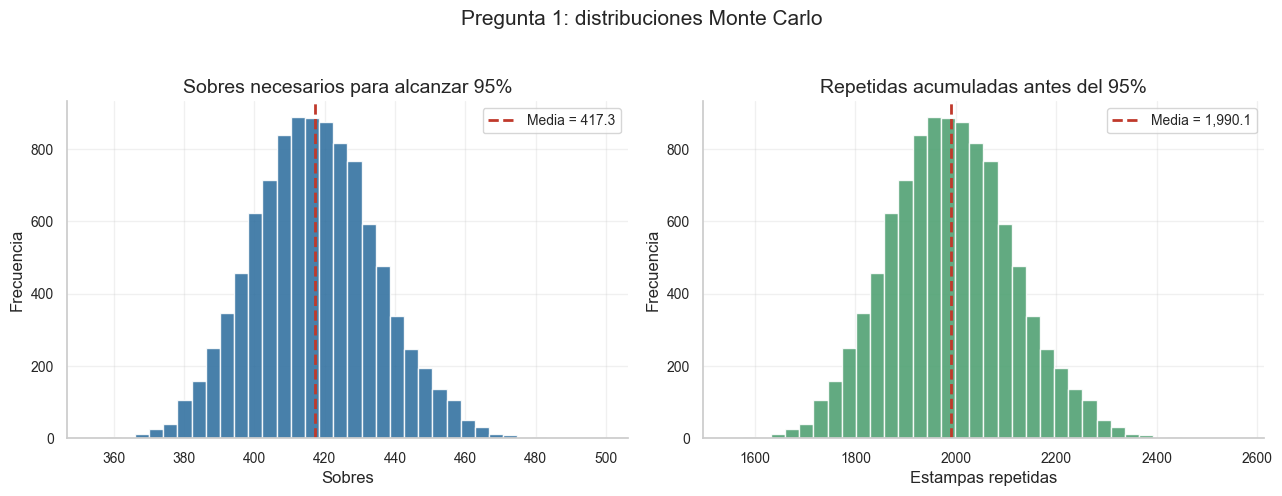

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(sobres_95, bins=36, color='#2f6f9f', alpha=0.88, edgecolor='white')
axes[0].axvline(sobres_95.mean(), color='#c0392b', linestyle='--', linewidth=2,
                label=f'Media = {sobres_95.mean():,.1f}')
axes[0].set_title('Sobres necesarios para alcanzar 95%')
axes[0].set_xlabel('Sobres')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(repetidas_95, bins=36, color='#4c9f70', alpha=0.88, edgecolor='white')
axes[1].axvline(repetidas_95.mean(), color='#c0392b', linestyle='--', linewidth=2,
                label=f'Media = {repetidas_95.mean():,.1f}')
axes[1].set_title('Repetidas acumuladas antes del 95%')
axes[1].set_xlabel('Estampas repetidas')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

fig.suptitle('Pregunta 1: distribuciones Monte Carlo', y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

**Interpretación.** Llegar al 95% del álbum es mucho más barato que completarlo totalmente, porque la parte final del Coupon Collector concentra la mayor dificultad. Aun así, antes del 95% ya se acumulan alrededor de dos mil repetidas en promedio.

---
## Pregunta 2

**Si una persona dispone de un presupuesto fijo de Q 3,000, ¿cuál es la probabilidad de conseguir al menos 900 estampas distintas?**

Metodología: siguiendo la etapa de presupuesto de `Lab08.ipynb`, primero se evalúa el caso de comprar únicamente sobres sueltos. Con Q 3,000 se pueden comprar:

\[
\left\lfloor \frac{3000}{9.50} \right\rfloor = 315 \text{ sobres}.
\]

Como referencia adicional, se muestra la mejor combinación de cajas y sobres sueltos bajo el mismo presupuesto; la comparación de estrategias se analiza formalmente en la Pregunta 4.

In [6]:
PRESUPUESTO_Q2 = 3_000.00
OBJ_Q2 = 900

sobres_sueltos_q2 = int(PRESUPUESTO_Q2 // PRECIO_SOBRE)
costo_sueltos_q2 = sobres_sueltos_q2 * PRECIO_SOBRE

combo_q2 = max_sobres_por_presupuesto(
    presupuesto=PRESUPUESTO_Q2,
    precio_sobre=PRECIO_SOBRE,
    precio_caja=PRECIO_CAJA,
    sobres_caja=SOBRES_CAJA,
)

print(f'Sobres sueltos comprables con Q3,000: {sobres_sueltos_q2}')
print(f'Costo usando solo sobres sueltos: {formato_q(costo_sueltos_q2)}')
print()
print('Mejor combinacion por cantidad de sobres bajo Q3,000:')
print(f"  Cajas: {combo_q2['cajas']}")
print(f"  Sobres sueltos: {combo_q2['sobres_sueltos']}")
print(f"  Sobres totales: {combo_q2['sobres_total']}")
print(f"  Costo: {formato_q(combo_q2['costo'])}")
print(f"  Sobrante: {formato_q(combo_q2['sobrante'])}")

Sobres sueltos comprables con Q3,000: 315
Costo usando solo sobres sueltos: Q 2,992.50

Mejor combinacion por cantidad de sobres bajo Q3,000:
  Cajas: 3
  Sobres sueltos: 7
  Sobres totales: 319
  Costo: Q 2,991.50
  Sobrante: Q 8.50


In [7]:
q2_sueltos = simular_m_sobres(
    N=N,
    S=S_BASE,
    M=sobres_sueltos_q2,
    R=R_BUDGET,
    seed=SEED + 2,
)

q2_combo = simular_m_sobres(
    N=N,
    S=S_BASE,
    M=combo_q2['sobres_total'],
    R=R_BUDGET,
    seed=SEED + 3,
)

prob_sueltos = np.mean(q2_sueltos['unicas'] >= OBJ_Q2)
prob_combo = np.mean(q2_combo['unicas'] >= OBJ_Q2)

ic_sueltos = ic_proporcion(prob_sueltos, R_BUDGET)
ic_combo = ic_proporcion(prob_combo, R_BUDGET)

resumen_q2 = pd.DataFrame([
    {
        'Estrategia': 'Solo sobres sueltos',
        'Sobres': sobres_sueltos_q2,
        'Costo': formato_q(costo_sueltos_q2),
        'Media distintas': q2_sueltos['unicas'].mean(),
        'P(distintas >= 900)': prob_sueltos,
        'IC 95% aprox.': f'± {ic_sueltos:.4f}',
    },
    {
        'Estrategia': 'Max. sobres con cajas + sueltos',
        'Sobres': combo_q2['sobres_total'],
        'Costo': formato_q(combo_q2['costo']),
        'Media distintas': q2_combo['unicas'].mean(),
        'P(distintas >= 900)': prob_combo,
        'IC 95% aprox.': f'± {ic_combo:.4f}',
    },
])

display(resumen_q2)

display(Markdown(
    f"""
**Resultado principal.** Bajo el supuesto de **solo sobres sueltos**, la probabilidad estimada de obtener al menos
**{OBJ_Q2} estampas distintas** con Q 3,000 es **{prob_sueltos:.4f}** (**{prob_sueltos:.2%}**).

Si se maximiza la cantidad de sobres combinando cajas y sobres sueltos, se compran **{combo_q2['sobres_total']} sobres** y la probabilidad sube a **{prob_combo:.4f}** (**{prob_combo:.2%}**), pero sigue siendo baja.
"""
))

,Estrategia,Sobres,Costo,Media distintas,P(distintas >= 900),IC 95% aprox.
0,Solo sobres sueltos,315,"Q 2,992.50",877.6100,0.0033,± 0.0008
1,Max. sobres con cajas + sueltos,319,"Q 2,991.50",880.4505,0.0089,± 0.0013



**Resultado principal.** Bajo el supuesto de **solo sobres sueltos**, la probabilidad estimada de obtener al menos
**900 estampas distintas** con Q 3,000 es **0.0033** (**0.33%**).

Si se maximiza la cantidad de sobres combinando cajas y sobres sueltos, se compran **319 sobres** y la probabilidad sube a **0.0089** (**0.89%**), pero sigue siendo baja.


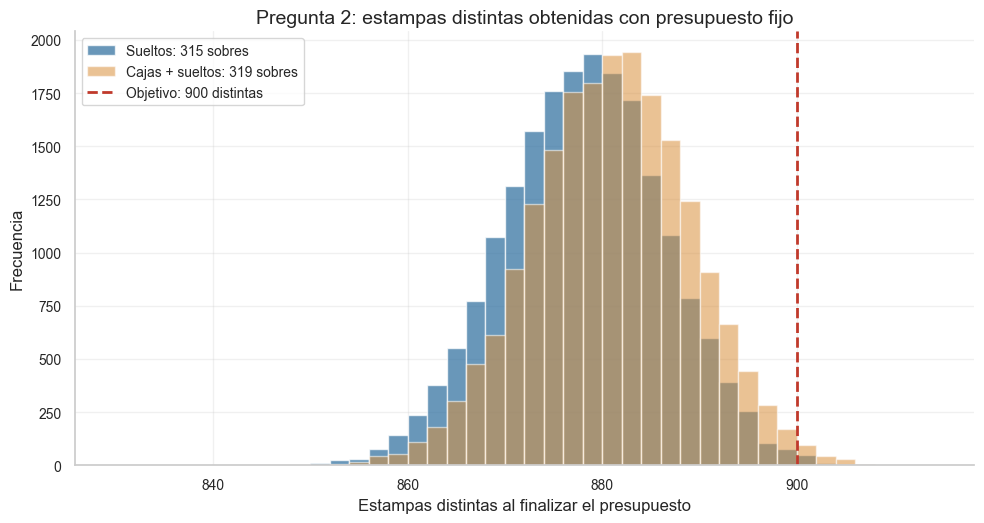

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.4))

bins = np.arange(830, 915, 2)
ax.hist(q2_sueltos['unicas'], bins=bins, alpha=0.72, color='#2f6f9f', edgecolor='white',
        label=f'Sueltos: {sobres_sueltos_q2} sobres')
ax.hist(q2_combo['unicas'], bins=bins, alpha=0.55, color='#d9903d', edgecolor='white',
        label=f'Cajas + sueltos: {combo_q2["sobres_total"]} sobres')
ax.axvline(OBJ_Q2, color='#c0392b', linestyle='--', linewidth=2, label='Objetivo: 900 distintas')

ax.set_title('Pregunta 2: estampas distintas obtenidas con presupuesto fijo')
ax.set_xlabel('Estampas distintas al finalizar el presupuesto')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** Con Q 3,000 se espera quedar cerca de 878 a 880 estampas distintas, dependiendo de la estrategia de compra. El umbral de 900 queda en la cola derecha de la distribución, por lo que la probabilidad estimada es pequeña.

---
## Pregunta 3

**¿Qué reduce más el número esperado de sobres necesarios para completar el álbum: aumentar el contenido del sobre de 7 a 8 estampas o permitir intercambios con tasa K = 5?**

Metodología: se comparan tres escenarios hasta completar las 980 estampas:

1. Base: `S = 7`, sin intercambio.
2. Sobre mejorado: `S = 8`, sin intercambio.
3. Intercambio: `S = 7`, cada `K = 5` repetidas se canjean por una faltante.

La regla de intercambio reutiliza la idea de `Lab08.ipynb`, pero aplicada por conteos para el álbum real.

In [9]:
q3_base = simular_hasta_objetivo(
    N=N,
    S=S_BASE,
    objetivo=OBJ_100,
    R=R_COMPLETAR,
    seed=SEED + 30,
)

q3_s8 = simular_hasta_objetivo(
    N=N,
    S=S_MEJORADO,
    objetivo=OBJ_100,
    R=R_COMPLETAR,
    seed=SEED + 31,
)

q3_k5 = simular_hasta_objetivo(
    N=N,
    S=S_BASE,
    objetivo=OBJ_100,
    R=R_COMPLETAR,
    seed=SEED + 32,
    K=5,
)

media_base = q3_base['sobres'].mean()
media_s8 = q3_s8['sobres'].mean()
media_k5 = q3_k5['sobres'].mean()

reduccion_s8 = media_base - media_s8
reduccion_k5 = media_base - media_k5

resumen_q3 = pd.DataFrame([
    {
        'Escenario': 'Base: S=7, sin intercambio',
        'Media sobres': media_base,
        'Desv. est.': q3_base['sobres'].std(ddof=1),
        'Mediana': np.median(q3_base['sobres']),
        'P95 sobres': quantil_superior(q3_base['sobres'], 0.95),
        'Reduccion vs base': 0.0,
        'Reduccion %': 0.0,
    },
    {
        'Escenario': 'S=8, sin intercambio',
        'Media sobres': media_s8,
        'Desv. est.': q3_s8['sobres'].std(ddof=1),
        'Mediana': np.median(q3_s8['sobres']),
        'P95 sobres': quantil_superior(q3_s8['sobres'], 0.95),
        'Reduccion vs base': reduccion_s8,
        'Reduccion %': reduccion_s8 / media_base,
    },
    {
        'Escenario': 'S=7, intercambio K=5',
        'Media sobres': media_k5,
        'Desv. est.': q3_k5['sobres'].std(ddof=1),
        'Mediana': np.median(q3_k5['sobres']),
        'P95 sobres': quantil_superior(q3_k5['sobres'], 0.95),
        'Reduccion vs base': reduccion_k5,
        'Reduccion %': reduccion_k5 / media_base,
    },
])

display(resumen_q3)

mejor = 'intercambio K=5' if reduccion_k5 > reduccion_s8 else 'aumentar el sobre a 8 estampas'

display(Markdown(
    f"""
**Resultado principal.** El cambio que mas reduce el numero esperado de sobres es **{mejor}**.

- Pasar de `S=7` a `S=8` reduce aproximadamente **{reduccion_s8:,.2f} sobres**.
- Permitir intercambio con `K=5` reduce aproximadamente **{reduccion_k5:,.2f} sobres**.
"""
))

,Escenario,Media sobres,Desv. est.,Mediana,P95 sobres,Reduccion vs base,Reduccion %
0,"Base: S=7, sin intercambio","1,043.0190",179.9439,"1,014.0000",1381,0.0000,0.0000
1,"S=8, sin intercambio",911.9203,155.3961,886.0000,1198,131.0987,0.1257
2,"S=7, intercambio K=5",280.9935,4.4568,281.0000,288,762.0255,0.7306



**Resultado principal.** El cambio que mas reduce el numero esperado de sobres es **intercambio K=5**.

- Pasar de `S=7` a `S=8` reduce aproximadamente **131.10 sobres**.
- Permitir intercambio con `K=5` reduce aproximadamente **762.03 sobres**.


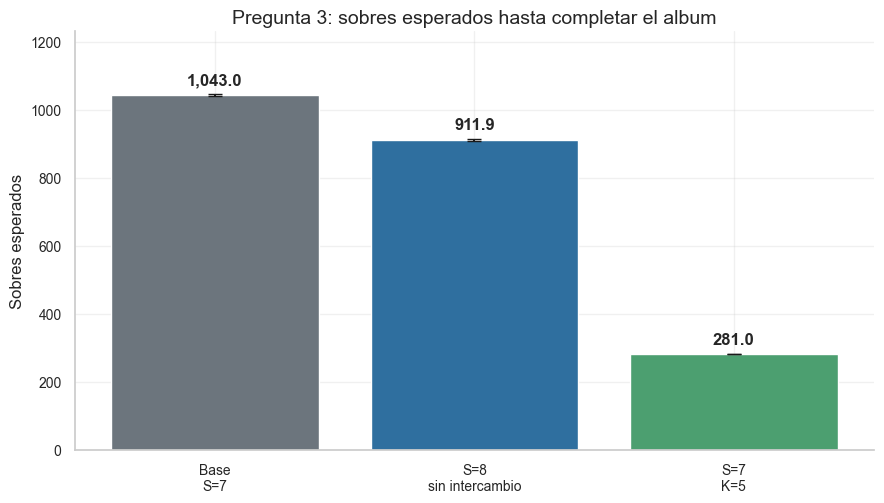

In [10]:
escenarios = ['Base\nS=7', 'S=8\nsin intercambio', 'S=7\nK=5']
medias = np.array([media_base, media_s8, media_k5])
errores = np.array([
    1.96 * q3_base['sobres'].std(ddof=1) / np.sqrt(R_COMPLETAR),
    1.96 * q3_s8['sobres'].std(ddof=1) / np.sqrt(R_COMPLETAR),
    1.96 * q3_k5['sobres'].std(ddof=1) / np.sqrt(R_COMPLETAR),
])
colores = ['#6c757d', '#2f6f9f', '#4c9f70']

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(escenarios, medias, yerr=errores, capsize=5, color=colores, edgecolor='white')

for bar, valor in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 22,
            f'{valor:,.1f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Pregunta 3: sobres esperados hasta completar el album')
ax.set_ylabel('Sobres esperados')
ax.set_ylim(0, max(medias) * 1.18)
plt.tight_layout()
plt.show()

**Interpretación.** Aumentar el contenido del sobre ayuda, pero el intercambio cambia la dinámica de la etapa final: las repetidas dejan de ser desperdicio completo y se transforman en progreso directo hacia las estampas faltantes. Por eso `K = 5` domina ampliamente a la mejora de 7 a 8 estampas por sobre.

---
## Pregunta 4

**¿Qué estrategia resulta más económica para completar el álbum con alta probabilidad: comprar únicamente sobres sueltos o comenzar comprando cajas y completar con sobres individuales?**

Metodología: se usa la distribución simulada del número de sobres necesarios para completar el álbum sin intercambio (`S = 7`). Para definir “alta probabilidad” se toma como referencia principal el 95%, y se reportan también 90% y 99% como sensibilidad.

La probabilidad de completar depende del número total de sobres abiertos; la diferencia entre estrategias es el costo de conseguir esa cantidad de sobres.

In [11]:
niveles_alta_prob = [0.90, 0.95, 0.99]
filas_q4 = []

for nivel in niveles_alta_prob:
    M_nivel = quantil_superior(q3_base['sobres'], nivel)
    prob_empirica = np.mean(q3_base['sobres'] <= M_nivel)

    costo_sueltos = M_nivel * PRECIO_SOBRE
    combo = costo_minimo_para_m_sobres(
        M=M_nivel,
        precio_sobre=PRECIO_SOBRE,
        precio_caja=PRECIO_CAJA,
        sobres_caja=SOBRES_CAJA,
    )

    filas_q4.append({
        'Prob. objetivo': f'{nivel:.0%}',
        'Sobres necesarios': M_nivel,
        'Prob. empirica': prob_empirica,
        'Costo solo sueltos': costo_sueltos,
        'Cajas estrategia mixta': combo['cajas'],
        'Sueltos estrategia mixta': combo['sobres_sueltos'],
        'Sobres totales mixta': combo['sobres_total'],
        'Costo cajas + sueltos': combo['costo'],
        'Ahorro': costo_sueltos - combo['costo'],
    })

resumen_q4 = pd.DataFrame(filas_q4)
display(resumen_q4)

fila_95 = resumen_q4.loc[resumen_q4['Prob. objetivo'] == '95%'].iloc[0]

display(Markdown(
    f"""
**Resultado principal.** Para una probabilidad cercana al **95%**, se requieren aproximadamente
**{int(fila_95['Sobres necesarios']):,} sobres**. Comprar solo sobres sueltos cuesta
**{formato_q(fila_95['Costo solo sueltos'])}**, mientras que la estrategia de cajas y sobres sueltos cuesta
**{formato_q(fila_95['Costo cajas + sueltos'])}**.

La estrategia mixta usa **{int(fila_95['Cajas estrategia mixta'])} cajas** y
**{int(fila_95['Sueltos estrategia mixta'])} sobres sueltos**, con un ahorro estimado de
**{formato_q(fila_95['Ahorro'])}** frente a comprar todo suelto.
"""
))

,Prob. objetivo,Sobres necesarios,Prob. empirica,Costo solo sueltos,Cajas estrategia mixta,Sueltos estrategia mixta,Sobres totales mixta,Costo cajas + sueltos,Ahorro
0,90%,1282,0.9004,"12,179.0000",12,34,1282,"12,023.0000",156.0000
1,95%,1381,0.9501,"13,119.5000",13,29,1381,"12,950.5000",169.0000
2,99%,1603,0.9901,"15,228.5000",15,43,1603,"15,033.5000",195.0000



**Resultado principal.** Para una probabilidad cercana al **95%**, se requieren aproximadamente
**1,381 sobres**. Comprar solo sobres sueltos cuesta
**Q 13,119.50**, mientras que la estrategia de cajas y sobres sueltos cuesta
**Q 12,950.50**.

La estrategia mixta usa **13 cajas** y
**29 sobres sueltos**, con un ahorro estimado de
**Q 169.00** frente a comprar todo suelto.


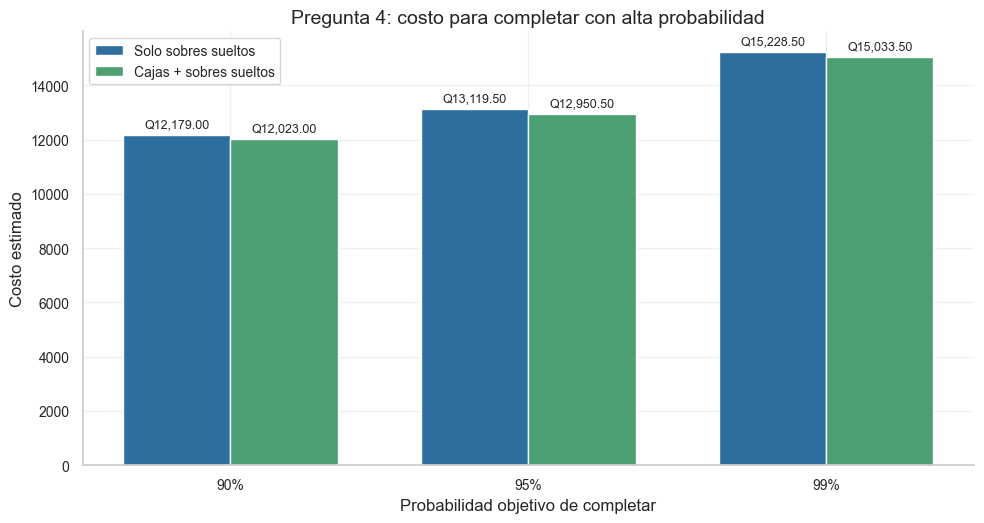

In [12]:
x = np.arange(len(resumen_q4))
ancho = 0.36

fig, ax = plt.subplots(figsize=(10, 5.4))

ax.bar(x - ancho / 2, resumen_q4['Costo solo sueltos'], width=ancho,
       color='#2f6f9f', edgecolor='white', label='Solo sobres sueltos')
ax.bar(x + ancho / 2, resumen_q4['Costo cajas + sueltos'], width=ancho,
       color='#4c9f70', edgecolor='white', label='Cajas + sobres sueltos')

for i, row in resumen_q4.iterrows():
    ax.text(i - ancho / 2, row['Costo solo sueltos'] + 180,
            formato_q(row['Costo solo sueltos']).replace('Q ', 'Q'),
            ha='center', va='bottom', fontsize=9)
    ax.text(i + ancho / 2, row['Costo cajas + sueltos'] + 180,
            formato_q(row['Costo cajas + sueltos']).replace('Q ', 'Q'),
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(resumen_q4['Prob. objetivo'])
ax.set_title('Pregunta 4: costo para completar con alta probabilidad')
ax.set_xlabel('Probabilidad objetivo de completar')
ax.set_ylabel('Costo estimado')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** La estrategia de cajas y sobres sueltos es más económica porque la caja tiene un precio promedio menor por sobre. La probabilidad de completar se mantiene igual o mejora si el número total de sobres es el mismo o mayor; por tanto, el ahorro proviene únicamente del descuento por caja.

---
## Pregunta 5

**Con intercambios favorables de K = 3, ¿cuál es la probabilidad de completar al menos el 80%, 90% y 100% del álbum después de comprar exactamente 1,200 sobres?**

Metodología: se simulan exactamente `1,200` sobres por coleccionista. Después de cada sobre, cada `K = 3` repetidas acumuladas se canjean por una estampa faltante. Al final se mide la proporción de corridas que alcanza los umbrales de 80%, 90% y 100%.

In [13]:
M_Q5 = 1_200
K_Q5 = 3

q5 = simular_m_sobres(
    N=N,
    S=S_BASE,
    M=M_Q5,
    R=R_GENERAL,
    seed=SEED + 50,
    K=K_Q5,
)

umbrales_q5 = [
    ('80%', OBJ_80),
    ('90%', OBJ_90),
    ('100%', OBJ_100),
]

filas_q5 = []
for etiqueta, objetivo in umbrales_q5:
    p = np.mean(q5['unicas'] >= objetivo)
    filas_q5.append({
        'Umbral': etiqueta,
        'Estampas requeridas': objetivo,
        'Probabilidad estimada': p,
        'IC 95% aprox.': f'± {ic_proporcion(p, R_GENERAL):.4f}',
    })

resumen_q5 = pd.DataFrame(filas_q5)
display(resumen_q5)

display(Markdown(
    f"""
**Resultado principal.** Con `K = {K_Q5}` y **{M_Q5:,} sobres**, la simulacion alcanza los tres umbrales en todas las corridas observadas:
80%, 90% y 100% tienen probabilidad estimada **1.0000**.

No se observaron fallos en **{R_GENERAL:,}** simulaciones. Como regla practica, si no aparece ningun fallo, la probabilidad de fallo compatible con la simulacion es menor a aproximadamente **{3 / R_GENERAL:.2%}**.
"""
))

,Umbral,Estampas requeridas,Probabilidad estimada,IC 95% aprox.
0,80%,784,1.0000,± 0.0000
1,90%,882,1.0000,± 0.0000
2,100%,980,1.0000,± 0.0000



**Resultado principal.** Con `K = 3` y **1,200 sobres**, la simulacion alcanza los tres umbrales en todas las corridas observadas:
80%, 90% y 100% tienen probabilidad estimada **1.0000**.

No se observaron fallos en **10,000** simulaciones. Como regla practica, si no aparece ningun fallo, la probabilidad de fallo compatible con la simulacion es menor a aproximadamente **0.03%**.


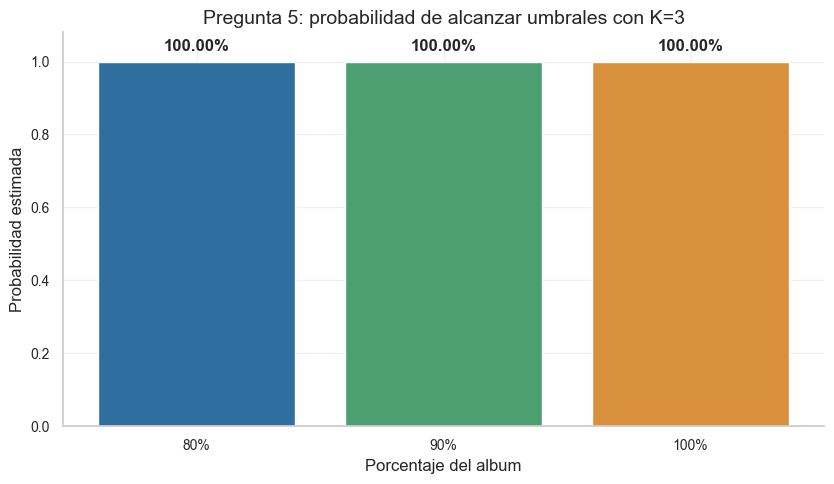

In [14]:
probabilidades_q5 = resumen_q5['Probabilidad estimada'].to_numpy()
etiquetas_q5 = resumen_q5['Umbral'].to_list()

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(etiquetas_q5, probabilidades_q5, color=['#2f6f9f', '#4c9f70', '#d9903d'], edgecolor='white')

for bar, p in zip(bars, probabilidades_q5):
    ax.text(bar.get_x() + bar.get_width() / 2, min(p + 0.02, 1.03),
            f'{p:.2%}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Pregunta 5: probabilidad de alcanzar umbrales con K=3')
ax.set_xlabel('Porcentaje del album')
ax.set_ylabel('Probabilidad estimada')
ax.set_ylim(0, 1.08)
plt.tight_layout()
plt.show()

**Interpretación.** Un intercambio tan favorable como `K = 3` vuelve extremadamente fuerte el efecto de las repetidas. Después de 1,200 sobres se han comprado 8,400 estampas físicas, de modo que las repetidas acumuladas son suficientes para cerrar las faltantes en todas las corridas simuladas.

---
## Conclusiones breves

1. Para alcanzar el 95% del álbum se requieren alrededor de 417 sobres y cerca de 1,990 repetidas acumuladas.
2. Con Q 3,000 en sobres sueltos, la probabilidad de llegar a 900 estampas distintas es baja; maximizar sobres con cajas ayuda, pero no cambia la conclusión principal.
3. Permitir intercambios con `K = 5` reduce mucho más el número esperado de sobres que aumentar el contenido del sobre de 7 a 8 estampas.
4. Para completar con alta probabilidad, comprar cajas y luego completar con sobres individuales es más económico que comprar únicamente sobres sueltos.
5. Con `K = 3` y 1,200 sobres, la simulación estima probabilidad 1.0000 de alcanzar 80%, 90% y 100% del álbum.

Los resultados dependen del modelo asumido: sobres sin repetidas internas, distribución uniforme de estampas y regla de intercambio ideal donde cada canje entrega una estampa faltante.